# Notebook 05 — Modelo de precipitación Bernoulli-Gamma

## 1. Preparación del modelo Bernoulli–Gamma

En esta etapa se construye la variable de ocurrencia de lluvia.
La precipitación se separa en dos procesos:

- Ocurrencia: si llueve o no (Bernoulli)
- Intensidad: cuánto llueve (Gamma)

Definimos una variable binaria `rain_flag` que indica días lluviosos.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

from scipy.stats import kurtosis

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from arch import arch_model

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ValueWarning)

In [2]:
# Leer el excel
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

# Renombrar columnas para ajustar a formato requerido
df.rename(
    columns={
        't_min': 'Temperature_Min_C',
        't_max': 'Temperature_Max_C',
        'precip': 'Precipitation_mm',
        'date': 'Date',
        "t_mean": "Temperature_Avg_C",
    },
    inplace=True,
)

# 1. Asegurar que la columna de fecha sea datetime desde el inicio
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filtrar los departamentos seleccionando solo las columnas requeridas y definiendo la fecha como índice
columnas_interes = ['Temperature_Avg_C', 'Temperature_Min_C', 'Temperature_Max_C', 'Precipitation_mm']

df_Casanare = df[df['department'] == 'Casanare'].set_index('Date')[columnas_interes].copy()
df_Tolima   = df[df['department'] == 'Tolima'].set_index('Date')[columnas_interes].copy()

# 3. Ver primeros registros 
#print("--- Casanare ---")
#print(df_Casanare.head())

#print("\n--- Tolima ---")
#print(df_Tolima.head())

## 2. Modelo de ocurrencia de lluvia (Bernoulli - Logit)

En este paso se modela la probabilidad de que ocurra lluvia en un día:

$$
P(P_t > 0) = p_t
$$

Usamos un modelo logístico (Logit), donde la variable dependiente es binaria:
- 1 = día con lluvia
- 0 = día sin lluvia

Se incorporan variables climáticas relevantes:
- Temperatura promedio
- Temperatura máxima
- Temperatura mínima

Estas variables ayudan a capturar cambios atmosféricos que afectan la ocurrencia de precipitación.

## 3. Estimación de probabilidad de lluvia

Con el modelo ajustado se calcula la probabilidad diaria de precipitación.

Esto será usado posteriormente para simular la ocurrencia de lluvia.

## 4. Modelo de intensidad de lluvia (Gamma)

Se modela la cantidad de precipitación en días lluviosos usando una distribución Gamma.

La media de la Gamma depende de variables climáticas:

- Temperatura promedio
- Temperatura máxima
- Temperatura mínima

Esto permite capturar cómo las condiciones térmicas afectan la intensidad de la lluvia.

## 5. Simulación del proceso completo de precipitación

Se simula la precipitación en dos etapas:

1. Bernoulli → determina si llueve o no
2. Gamma → genera intensidad si hay lluvia

La simulación usa los parámetros estimados del modelo ajustado.

## 6. Validación Multi-Escala de Precipitación

## Modelo Bernoulli-Gamma (BG)

**1. Logit — Ocurrencia de lluvia**

$$P(\text{llueve}) = \sigma\bigl(\beta_0 + \beta_1\sin(m) + \beta_2\cos(m) + \beta_3 T + \beta_4 y_{t-1} + \beta_5 y_{t-2}\bigr)$$

> $\sigma$ = sigmoide · $m$ = mes (cíclico) · $T$ = temperatura · $y_{t-k}$ = lags de precipitación

---

**2. GLM Gamma — Intensidad | llueve**

$$E[y \mid \text{llueve}] = \exp(X\beta)$$

> Enlace logarítmico. Solo se ajusta sobre días con `rain_flag = 1`.

---

**3. Predicción BG**

$$\hat{y}_{BG} = P(\text{llueve}) \times E[y \mid \text{llueve}]$$

---

## Corrección ARMA-GARCH sobre Residuales

**4. Residuales**

$$\varepsilon_t = y_t - \hat{y}_{BG,t}$$

---

**5. ARMA(p, q) — seleccionado por AIC mínimo, $p,q \in \{0\ldots3\}$**

$$\varepsilon_t = \sum_{i=1}^{p}\phi_i\,\varepsilon_{t-i} + \sum_{j=1}^{q}\theta_j\,\eta_{t-j} + \eta_t$$

---

**6. GARCH(1,1) sobre $\eta_t$**

$$\sigma^2_t = \omega + \alpha\,\eta^2_{t-1} + \beta\,\sigma^2_{t-1}$$

> Distribución: Normal si curtosis $\leq 3.2$, t-Student si curtosis $> 3.2$

---

**7. Predicción final BG + ARMA-GARCH**

$$\hat{y}_{BG+AG} = \max\!\bigl(0,\; \hat{y}_{BG} + \widehat{ARMA}_t\bigr)$$

---

## Selección del Mejor Modelo (out-of-sample, 20% test)

$$MAE = \frac{1}{n}\sum|y_t - \hat{y}_t| \qquad RMSE = \sqrt{\frac{1}{n}\sum(y_t - \hat{y}_t)^2}$$

> Ganador = menor MAE. Los parámetros $(\omega,\, \alpha,\, \beta,\, df_t,\, \sigma)$ se exportan para simulación Montecarlo.

In [3]:
# =============================================================================
# VALIDACIÓN MULTI-ESCALA DE PRECIPITACIÓN
# -----------------------------------------------------------------------------
# Este módulo ajusta y valida dos modelos estadísticos para precipitación:
#
#   1. Bernoulli-Gamma (BG):
#      - Un modelo logístico (Logit) predice si llueve o no (ocurrencia).
#      - Un modelo Gamma predice cuánto llueve cuando sí ocurre (intensidad).
#      - La predicción final es: P(lluvia) × Intensidad_esperada
#
#   2. BG + ARMA-GARCH:
#      - Toma los residuales del modelo BG y les ajusta un ARMA para capturar
#        autocorrelación temporal, y luego un GARCH para capturar volatilidad
#        cambiante en el tiempo (heterocedasticidad).
#
# El proceso completo incluye:
#   - División train/test (80/20) para validación out-of-sample
#   - Pruebas de normalidad sobre los residuales
#   - Selección automática del orden ARMA por AIC
#   - Selección automática de distribución GARCH según curtosis
#   - Exportación de parámetros listos para simulación Montecarlo
# =============================================================================

# =============================================================================
# FUNCIÓN PRINCIPAL
# =============================================================================

def validar_modelos_precipitacion(
    df_dpto,
    nombre_dpto,
    frecuencia='mensual',
    threshold=5
):
    """
    Ajusta y valida los modelos BG y BG+ARMA-GARCH para precipitación.

    Parámetros
    ----------
    df_dpto : pd.DataFrame
        Series de tiempo con al menos las columnas:
            - 'Precipitation_mm'  : precipitación en milímetros
            - 'Temperature_Avg_C' : temperatura promedio en °C
        El índice debe ser un DatetimeIndex.

    nombre_dpto : str
        Nombre del departamento (se usa en títulos de gráficas y mensajes).

    frecuencia : str
        Escala temporal para agregar residuales y métricas.
        Opciones: 'diaria', 'mensual', 'trimestral', 'semestral', 'anual'.

    threshold : float
        Umbral en mm para definir un día como "lluvioso".
        Si Precipitation_mm > threshold → rain_flag = 1.

    Retorna
    -------
    dict con las siguientes llaves:
        - 'tabla_resultados'     : DataFrame con RMSE y MAE de cada modelo
        - 'parametros_montecarlo': dict con parámetros para simulación MC
        - 'modelo_logit'         : modelo Logit ajustado (ocurrencia)
        - 'modelo_gamma'         : modelo Gamma ajustado (intensidad)
        - 'arma_model'           : modelo ARMA ajustado sobre residuales BG
        - 'garch_fit'            : modelo GARCH ajustado sobre residuales ARMA
    """

    # -------------------------------------------------------------------------
    # PASO 0: Validar y mapear frecuencia
    # -------------------------------------------------------------------------
    # Traducimos el nombre amigable de frecuencia al código de pandas resample.

    FRECUENCIAS_VALIDAS = {
        'diaria':      'D',
        'mensual':     'ME',
        'trimestral':  'QE',
        'semestral':   '6ME',
        'anual':       'YE'
    }

    frec_code = FRECUENCIAS_VALIDAS.get(frecuencia.lower())

    if frec_code is None:
        raise ValueError(
            f"Frecuencia '{frecuencia}' no válida. "
            f"Opciones: {list(FRECUENCIAS_VALIDAS.keys())}"
        )

    print("\n" + "=" * 85)
    print(f"  VALIDACIÓN PRECIPITACIÓN ({frecuencia.upper()}) — {nombre_dpto.upper()}")
    print("=" * 85)

    # -------------------------------------------------------------------------
    # PASO 1: Ingeniería de características
    # -------------------------------------------------------------------------
    # Creamos variables que capturan estacionalidad (mes del año) y
    # dependencia temporal (precipitación de los dos días anteriores).

    df = df_dpto.copy()
    df['month'] = df.index.month

    # Codificación cíclica del mes: evita que enero (1) y diciembre (12)
    # parezcan "lejos" numéricamente cuando en realidad son consecutivos.
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

    # Lags de precipitación: capturan persistencia (si ayer llovió, hoy
    # es más probable que también llueva).
    df['lag1_precip'] = df['Precipitation_mm'].shift(1)
    df['lag2_precip'] = df['Precipitation_mm'].shift(2)

    # Variable respuesta binaria: 1 = llueve, 0 = no llueve
    df['rain_flag'] = (df['Precipitation_mm'] > threshold).astype(int)

    # Eliminamos filas con NaN generadas por los lags
    df = df.dropna()

    # -------------------------------------------------------------------------
    # PASO 2: División train / test (80% / 20%)
    # -------------------------------------------------------------------------

    split_idx = int(len(df) * 0.80)
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]

    # Variables explicativas usadas en ambos modelos (Logit y Gamma)
    VARS_EXPLICATIVAS = [
        'sin_month',        # estacionalidad (componente seno)
        'cos_month',        # estacionalidad (componente coseno)
        'Temperature_Avg_C',# temperatura como proxy climático
        'lag1_precip',      # precipitación del día anterior
        'lag2_precip'       # precipitación de hace dos días
    ]

    X_train = sm.add_constant(train[VARS_EXPLICATIVAS])

    # -------------------------------------------------------------------------
    # PASO 3: Modelo Logit — Ocurrencia de lluvia (Bernoulli)
    # -------------------------------------------------------------------------
    # Estima P(llueve hoy | condiciones actuales).
    # Usamos BFGS como optimizador porque es más estable con datos no balanceados.

    modelo_logit = sm.Logit(
        train['rain_flag'],
        X_train
    ).fit(method='bfgs', disp=0)

    # -------------------------------------------------------------------------
    # PASO 4: Modelo Gamma — Intensidad de lluvia (solo días con lluvia)
    # -------------------------------------------------------------------------
    # Solo ajustamos sobre días donde realmente llovió (rain_flag == 1).
    # La distribución Gamma es apropiada para valores positivos sesgados
    # como la intensidad de lluvia. Usamos enlace logarítmico para garantizar
    # que las predicciones sean siempre positivas.

    train_lluvia = train[train['rain_flag'] == 1]
    X_gamma      = sm.add_constant(train_lluvia[VARS_EXPLICATIVAS])

    modelo_gamma = sm.GLM(
        train_lluvia['Precipitation_mm'],
        X_gamma,
        family=sm.families.Gamma(link=sm.families.links.Log())
    ).fit()

    # -------------------------------------------------------------------------
    # PASO 5: Predicción BG en train y cálculo de residuales
    # -------------------------------------------------------------------------
    # Predicción BG = P(llueve) × Intensidad_esperada
    # Los residuales capturan todo lo que el modelo BG no explica.

    p_ocurrencia_train  = modelo_logit.predict(X_train)
    intensidad_train    = np.clip(modelo_gamma.predict(X_train), 0, 200)
    pred_bg_train       = p_ocurrencia_train * intensidad_train

    residuales_train = train['Precipitation_mm'] - pred_bg_train

    # -------------------------------------------------------------------------
    # PASO 6: Análisis de residuales
    # -------------------------------------------------------------------------
    # Agregamos los residuales a la frecuencia deseada para evaluar su
    # distribución y si tienen estructura temporal remanente.

    residuales_eval = residuales_train.resample(frec_code).mean().dropna()

    # --- Pruebas de normalidad ---
    print("\n[1] PRUEBAS DE NORMALIDAD SOBRE RESIDUALES")

    jb_stat,     jb_p     = stats.jarque_bera(residuales_eval)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        shapiro_stat, shapiro_p = stats.shapiro(residuales_eval)

    print(f"    Jarque-Bera  p-value : {jb_p:.5f}")
    print(f"    Shapiro-Wilk p-value : {shapiro_p:.5f}")

    if jb_p < 0.05:
        print("\n    → Se rechaza normalidad (p < 0.05)")
        print("    → Justificado usar distribución t-Student en Montecarlo")
    else:
        print("\n    → No se rechaza normalidad")

    # --- Ajuste de distribuciones para Montecarlo ---
    print("\n[2] AJUSTE DISTRIBUCIONAL DE RESIDUALES")

    mu_norm, sigma_norm       = stats.norm.fit(residuales_eval)
    df_t, loc_t, scale_t      = stats.t.fit(residuales_eval)

    print(f"    Normal    → mu={mu_norm:.4f}, sigma={sigma_norm:.4f}")
    print(f"    t-Student → df={df_t:.2f}, loc={loc_t:.4f}, scale={scale_t:.4f}")

    # -------------------------------------------------------------------------
    # PASO 7: Selección automática de orden ARMA
    # -------------------------------------------------------------------------
    # Probamos todas las combinaciones ARMA(p, q) con p,q ∈ {0,1,2,3}
    # y seleccionamos la que minimiza el AIC (criterio de información de Akaike).

    print("\n[3] BÚSQUEDA DEL ORDEN ARMA ÓPTIMO (por AIC)")

    mejor_aic   = np.inf
    mejor_orden = (1, 1)

    for p in range(4):
        for q in range(4):
            if p == 0 and q == 0:
                continue  # ARMA(0,0) es un modelo trivial (ruido blanco puro)
            try:
                modelo_prueba = ARIMA(residuales_train, order=(p, 0, q)).fit()
                if modelo_prueba.aic < mejor_aic:
                    mejor_aic   = modelo_prueba.aic
                    mejor_orden = (p, q)
            except Exception:
                continue  # Algunas combinaciones no convergen; las ignoramos

    p_opt, q_opt = mejor_orden
    print(f"    Mejor modelo: ARMA({p_opt},{q_opt})  |  AIC = {mejor_aic:.2f}")

    # Ajuste del ARMA final con el orden óptimo
    arma_model  = ARIMA(residuales_train, order=(p_opt, 0, q_opt)).fit()
    arma_resid  = arma_model.resid

    # -------------------------------------------------------------------------
    # PASO 8: Ajuste GARCH sobre residuales ARMA
    # -------------------------------------------------------------------------
    # Si los residuales del ARMA tienen colas pesadas (curtosis > 3.2),
    # usamos distribución t-Student en el GARCH; en caso contrario, Normal.
    # GARCH(1,1) captura la volatilidad agrupada (días muy lluviosos o muy secos
    # tienden a agruparse).

    print("\n[4] AJUSTE GARCH SOBRE RESIDUALES ARMA")

    curtosis_arma = kurtosis(arma_resid, fisher=False)
    dist_garch    = 't' if curtosis_arma > 3.2 else 'normal'

    print(f"    Curtosis de residuales ARMA : {curtosis_arma:.3f}")
    print(f"    Distribución GARCH elegida  : {dist_garch}")

    garch_model = arch_model(
        arma_resid,
        mean='Zero',   # El ARMA ya removió la media; el GARCH solo modela varianza
        vol='GARCH',
        p=1, q=1,
        dist=dist_garch
    )
    garch_fit = garch_model.fit(disp='off')

    # -------------------------------------------------------------------------
    # PASO 9: Predicciones out-of-sample en el conjunto test
    # -------------------------------------------------------------------------

    X_test = sm.add_constant(test[VARS_EXPLICATIVAS])

    # Predicción BG en test
    p_ocurrencia_test  = modelo_logit.predict(X_test)
    intensidad_test    = np.clip(modelo_gamma.predict(X_test), 0, 200)
    pred_bg_test       = p_ocurrencia_test * intensidad_test

    # Predicción BG + ARMA: sumamos el pronóstico del ARMA a la predicción BG.
    # Esto corrige el sesgo sistemático que el modelo BG deja en los residuales.
    arma_forecast = arma_model.forecast(steps=len(test))
    pred_bg_garch = np.clip(pred_bg_test.values + arma_forecast.values, 0, None)

    # -------------------------------------------------------------------------
    # PASO 10: Agregación y métricas
    # -------------------------------------------------------------------------

    df_result = pd.DataFrame({
        'Real':     test['Precipitation_mm'],
        'BG':       pred_bg_test,
        'BG_GARCH': pred_bg_garch
    }, index=test.index).resample(frec_code).sum()

    rmse_bg    = np.sqrt(mean_squared_error(df_result['Real'], df_result['BG']))
    rmse_garch = np.sqrt(mean_squared_error(df_result['Real'], df_result['BG_GARCH']))
    mae_bg     = mean_absolute_error(df_result['Real'], df_result['BG'])
    mae_garch  = mean_absolute_error(df_result['Real'], df_result['BG_GARCH'])

    tabla_resultados = pd.DataFrame({
        'Modelo': ['Bernoulli-Gamma', 'BG + ARMA-GARCH'],
        'RMSE':   [rmse_bg,  rmse_garch],
        'MAE':    [mae_bg,   mae_garch]
    })

    print("\n[5] RESULTADOS OUT-OF-SAMPLE")
    print(tabla_resultados.round(3).to_string(index=False))

    # El mejor modelo se elige por MAE (más robusto a outliers que RMSE)
    mejor_modelo = 'BG + ARMA-GARCH' if mae_garch < mae_bg else 'Bernoulli-Gamma'

    print(f"\n[6] MEJOR MODELO: {mejor_modelo}")

    # -------------------------------------------------------------------------
    # PASO 11: Parámetros para simulación Montecarlo
    # -------------------------------------------------------------------------
    # Exportamos todos los parámetros necesarios para que otro módulo
    # pueda simular series sintéticas de precipitación con el mismo
    # comportamiento estadístico observado en los datos.

    print("\n" + "*" * 85)
    print("  PARÁMETROS PARA SIMULACIÓN MONTECARLO")
    print("*" * 85)

    parametros_mc = {
        # Modelo ganador
        'modelo_optimo':    mejor_modelo,

        # Umbral de ocurrencia de lluvia
        'threshold_lluvia': threshold,

        # Orden del ARMA óptimo
        'arma_p':           p_opt,
        'arma_q':           q_opt,

        # Parámetros GARCH(1,1)
        # omega: varianza base; alpha: impacto de shocks pasados;
        # beta:  persistencia de volatilidad
        'garch_omega':      garch_fit.params.get('omega',    0),
        'garch_alpha':      garch_fit.params.get('alpha[1]', 0),
        'garch_beta':       garch_fit.params.get('beta[1]',  0),
        'dist_garch':       dist_garch,

        # Parámetros de la t-Student ajustada a los residuales BG
        't_df':             df_t,
        't_loc':            loc_t,
        't_scale':          scale_t,

        # Parámetros de la Normal ajustada (alternativa más simple)
        'normal_mu':        mu_norm,
        'normal_sigma':     sigma_norm
    }

    for clave, valor in parametros_mc.items():
        print(f"    {clave:20s}: {valor:.6f}" if isinstance(valor, float) else f"    {clave:20s}: {valor}")

    print("*" * 85)

    # -------------------------------------------------------------------------
    # PASO 12: Gráficas de diagnóstico
    # -------------------------------------------------------------------------

    _graficar_diagnostico(
        residuales_eval, mu_norm, sigma_norm, df_t, loc_t, scale_t,
        frecuencia, nombre_dpto
    )

    _graficar_oos(df_result, nombre_dpto)

    # -------------------------------------------------------------------------
    # RETORNO
    # -------------------------------------------------------------------------

    return {
        'tabla_resultados':      tabla_resultados,
        'parametros_montecarlo': parametros_mc,
        'modelo_logit':          modelo_logit,
        'modelo_gamma':          modelo_gamma,
        'arma_model':            arma_model,
        'garch_fit':             garch_fit
    }


# =============================================================================
# FUNCIONES AUXILIARES DE GRAFICACIÓN
# =============================================================================

def _graficar_diagnostico(
    residuales, mu_norm, sigma_norm,
    df_t, loc_t, scale_t,
    frecuencia, nombre_dpto
):
    """
    Genera tres paneles de diagnóstico sobre los residuales:
      - Histograma con ajuste Normal y t-Student superpuesto
      - Q-Q Plot vs. distribución Normal
      - Función de autocorrelación (ACF)
    """
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f'Diagnóstico de Residuales ({frecuencia.capitalize()}) — {nombre_dpto}',
        fontsize=15, fontweight='bold'
    )

    x = np.linspace(residuales.min(), residuales.max(), 400)

    # --- Panel izquierdo: Histograma + distribuciones ajustadas ---
    ax1 = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax1.hist(residuales, bins=40, density=True, alpha=0.5, label='Residuales')
    ax1.plot(x, stats.norm.pdf(x, mu_norm, sigma_norm),
             lw=2, label='Normal ajustada')
    ax1.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t),
             lw=2, linestyle='--', label='t-Student ajustada')
    ax1.set_title('Distribución de Residuales')
    ax1.set_xlabel('Residual (mm)')
    ax1.set_ylabel('Densidad')
    ax1.legend()
    ax1.grid(alpha=0.25)

    # --- Panel superior derecho: Q-Q Plot ---
    ax2 = plt.subplot2grid((2, 2), (0, 1))
    sm.qqplot(residuales, stats.norm, fit=True, line='45', ax=ax2)
    ax2.set_title('Q-Q Plot (Normal)')

    # --- Panel inferior derecho: ACF ---
    ax3 = plt.subplot2grid((2, 2), (1, 1))
    max_lags = min(30, len(residuales) // 4)
    plot_acf(residuales, lags=max_lags, ax=ax3)
    ax3.set_title('Autocorrelación de Residuales')

    plt.tight_layout()
    plt.show()


def _graficar_oos(df_result, nombre_dpto):
    """
    Grafica la comparación entre valores reales y predicciones
    de ambos modelos en el período de prueba (out-of-sample).
    """
    fig, ax = plt.subplots(figsize=(15, 6))

    ax.plot(df_result.index, df_result['Real'],
            color='black', lw=1.4, label='Real')
    ax.plot(df_result.index, df_result['BG'],
            linestyle='--', lw=1.3, label='Bernoulli-Gamma')
    ax.plot(df_result.index, df_result['BG_GARCH'],
            linestyle='-.', lw=1.3, label='BG + ARMA-GARCH')

    ax.set_title(f'Validación Out-of-Sample — {nombre_dpto}')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precipitación (mm)')
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()


  VALIDACIÓN PRECIPITACIÓN (MENSUAL) — CASANARE

[1] PRUEBAS DE NORMALIDAD SOBRE RESIDUALES
    Jarque-Bera  p-value : 0.00000
    Shapiro-Wilk p-value : 0.00000

    → Se rechaza normalidad (p < 0.05)
    → Justificado usar distribución t-Student en Montecarlo

[2] AJUSTE DISTRIBUCIONAL DE RESIDUALES
    Normal    → mu=0.1178, sigma=1.3294
    t-Student → df=1.83, loc=0.4978, scale=0.6070

[3] BÚSQUEDA DEL ORDEN ARMA ÓPTIMO (por AIC)
    Mejor modelo: ARMA(3,3)  |  AIC = 31204.26

[4] AJUSTE GARCH SOBRE RESIDUALES ARMA
    Curtosis de residuales ARMA : 156.534
    Distribución GARCH elegida  : t

[5] RESULTADOS OUT-OF-SAMPLE
         Modelo   RMSE    MAE
Bernoulli-Gamma 40.272 32.472
BG + ARMA-GARCH 38.231 29.959

[6] MEJOR MODELO: BG + ARMA-GARCH

*************************************************************************************
  PARÁMETROS PARA SIMULACIÓN MONTECARLO
*************************************************************************************
    modelo_optimo       : B

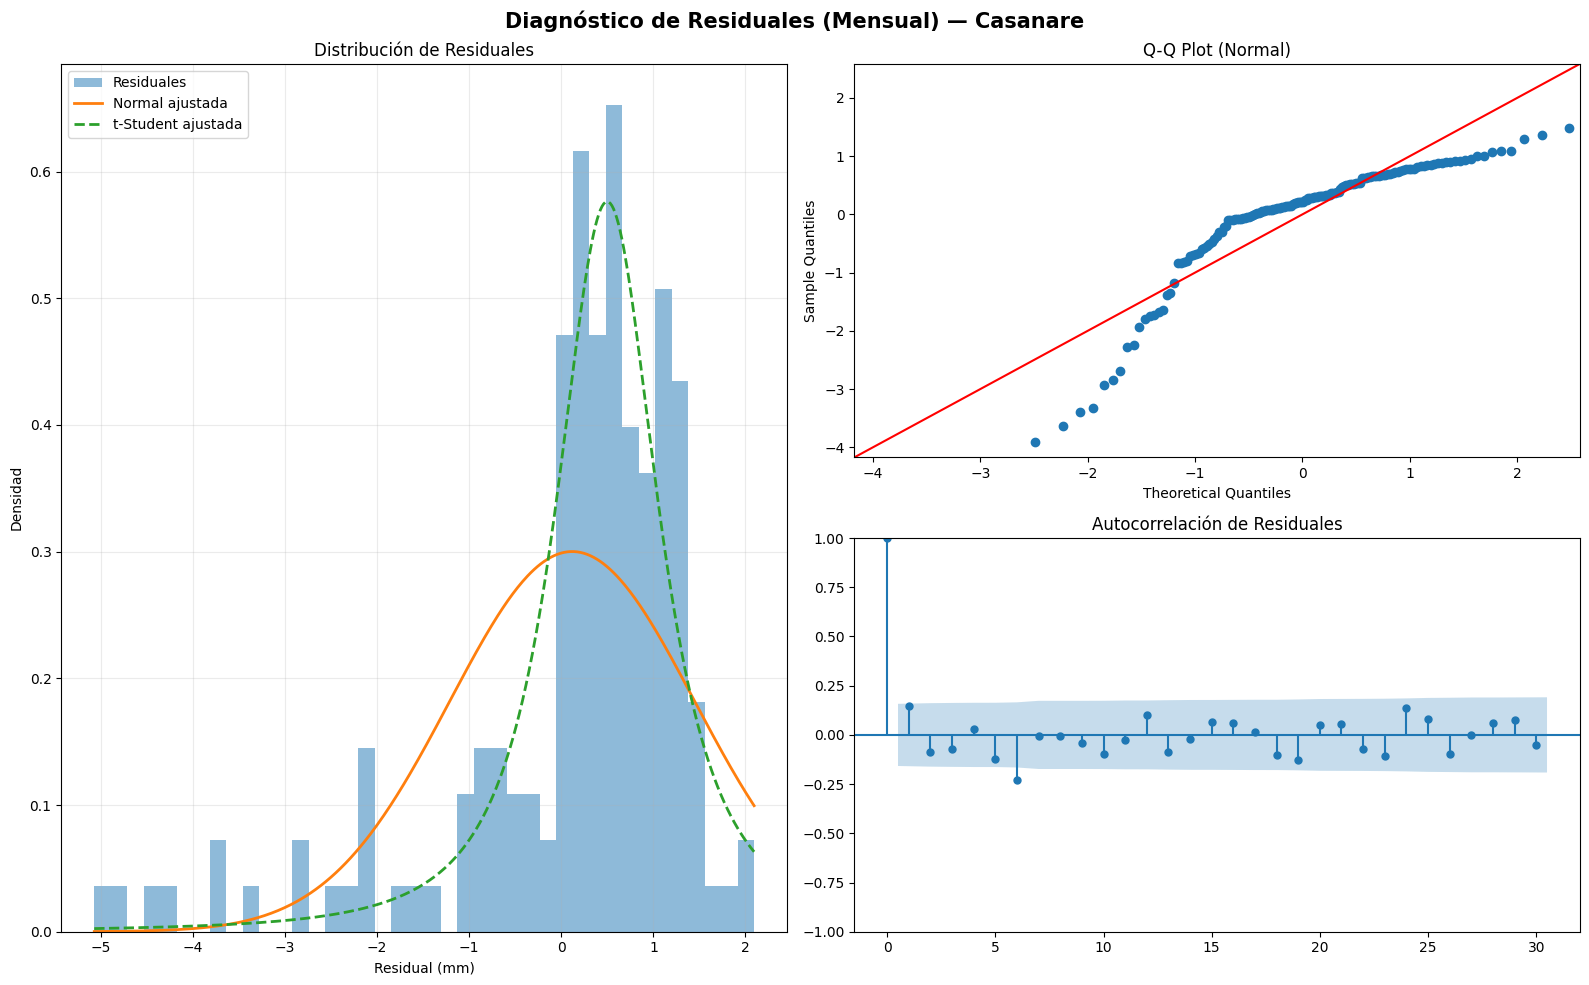

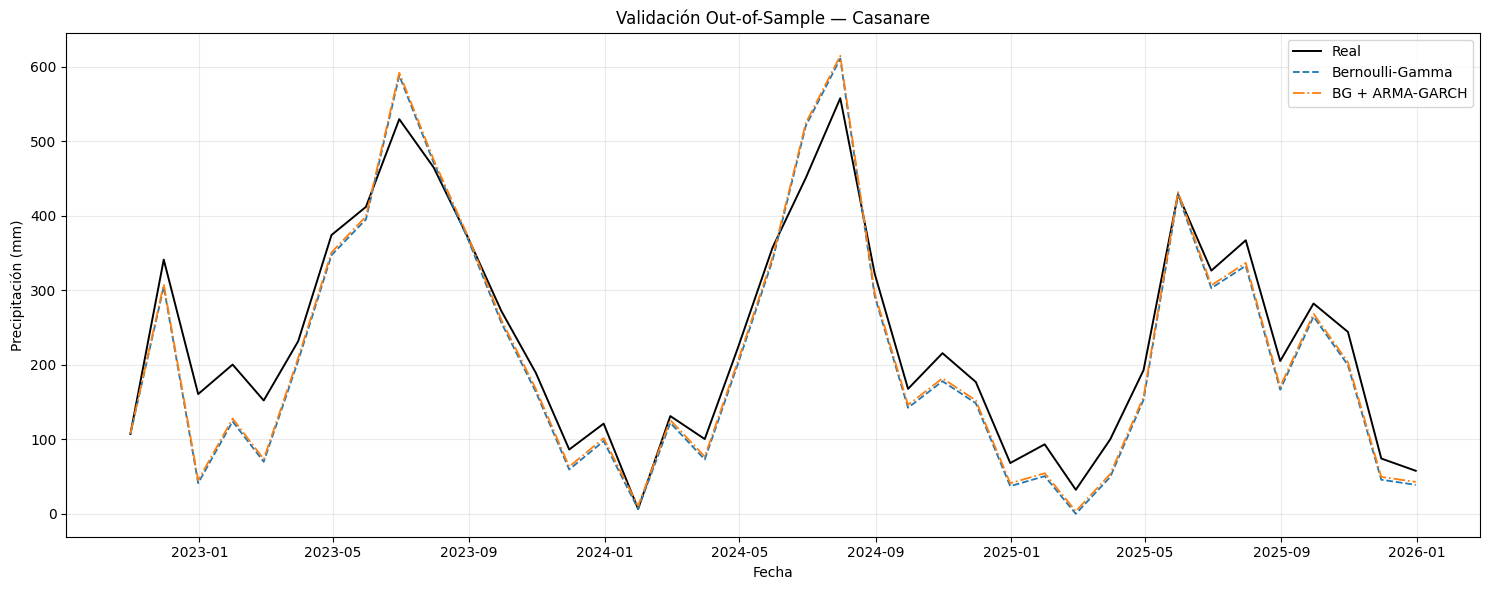


  VALIDACIÓN PRECIPITACIÓN (MENSUAL) — TOLIMA

[1] PRUEBAS DE NORMALIDAD SOBRE RESIDUALES
    Jarque-Bera  p-value : 0.00000
    Shapiro-Wilk p-value : 0.00000

    → Se rechaza normalidad (p < 0.05)
    → Justificado usar distribución t-Student en Montecarlo

[2] AJUSTE DISTRIBUCIONAL DE RESIDUALES
    Normal    → mu=0.6820, sigma=0.8509
    t-Student → df=2.40, loc=0.8340, scale=0.4419

[3] BÚSQUEDA DEL ORDEN ARMA ÓPTIMO (por AIC)
    Mejor modelo: ARMA(3,3)  |  AIC = 26694.13

[4] AJUSTE GARCH SOBRE RESIDUALES ARMA
    Curtosis de residuales ARMA : 436.967
    Distribución GARCH elegida  : t

[5] RESULTADOS OUT-OF-SAMPLE
         Modelo   RMSE    MAE
Bernoulli-Gamma 27.941 22.304
BG + ARMA-GARCH 25.590 15.024

[6] MEJOR MODELO: BG + ARMA-GARCH

*************************************************************************************
  PARÁMETROS PARA SIMULACIÓN MONTECARLO
*************************************************************************************
    modelo_optimo       : BG 

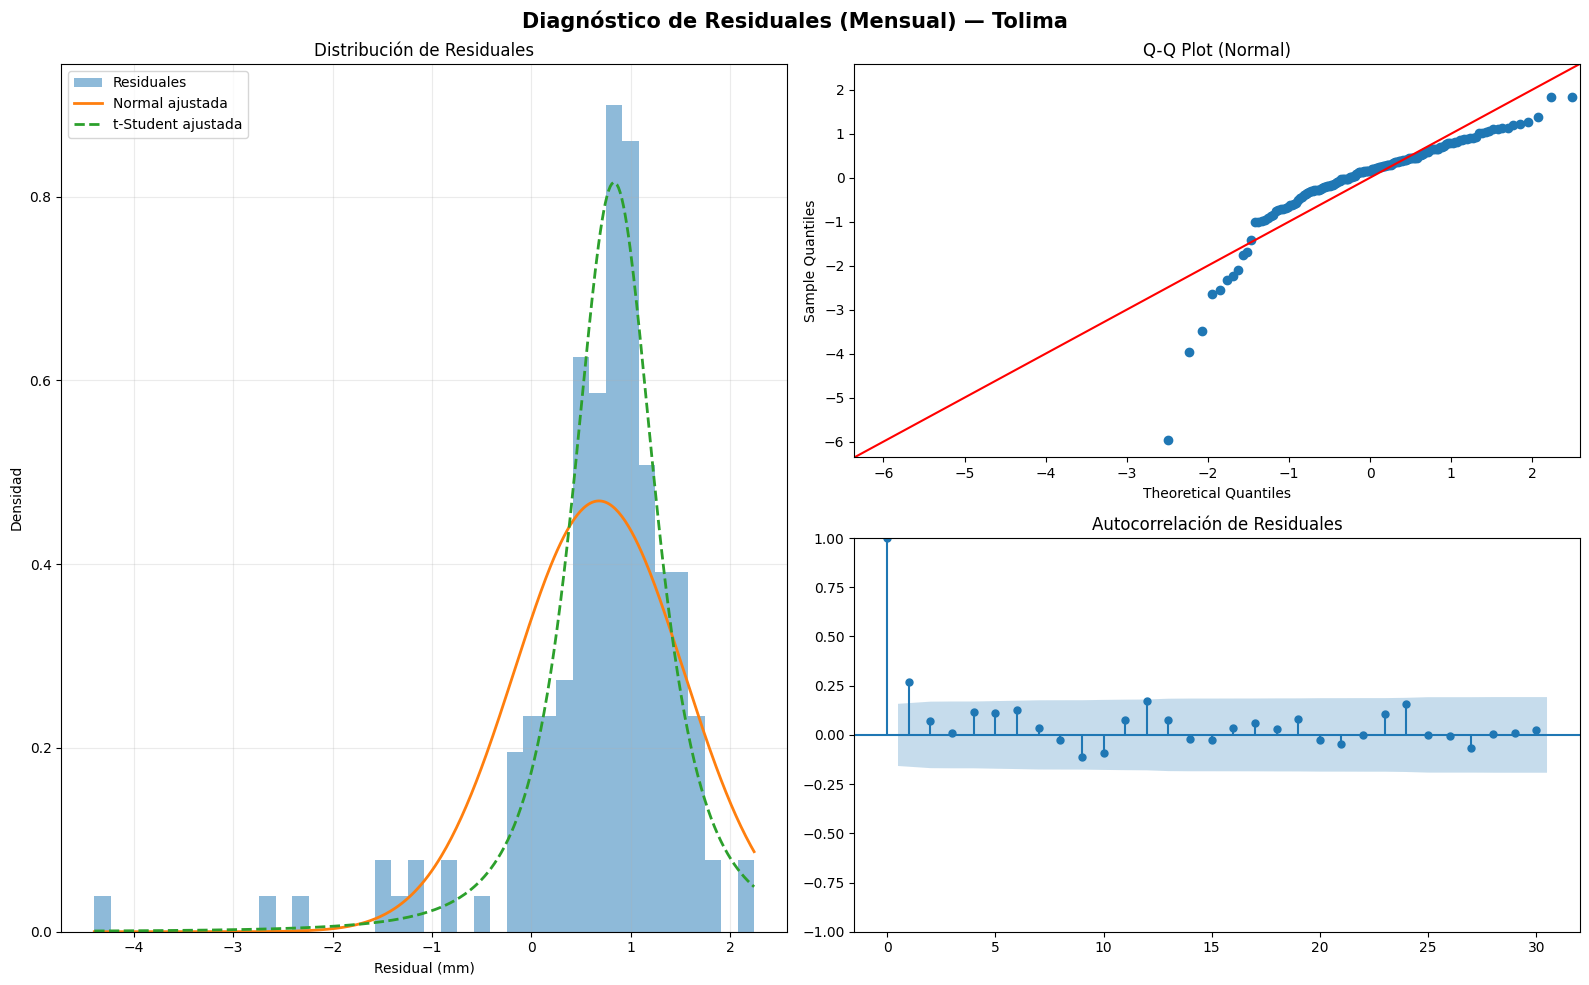

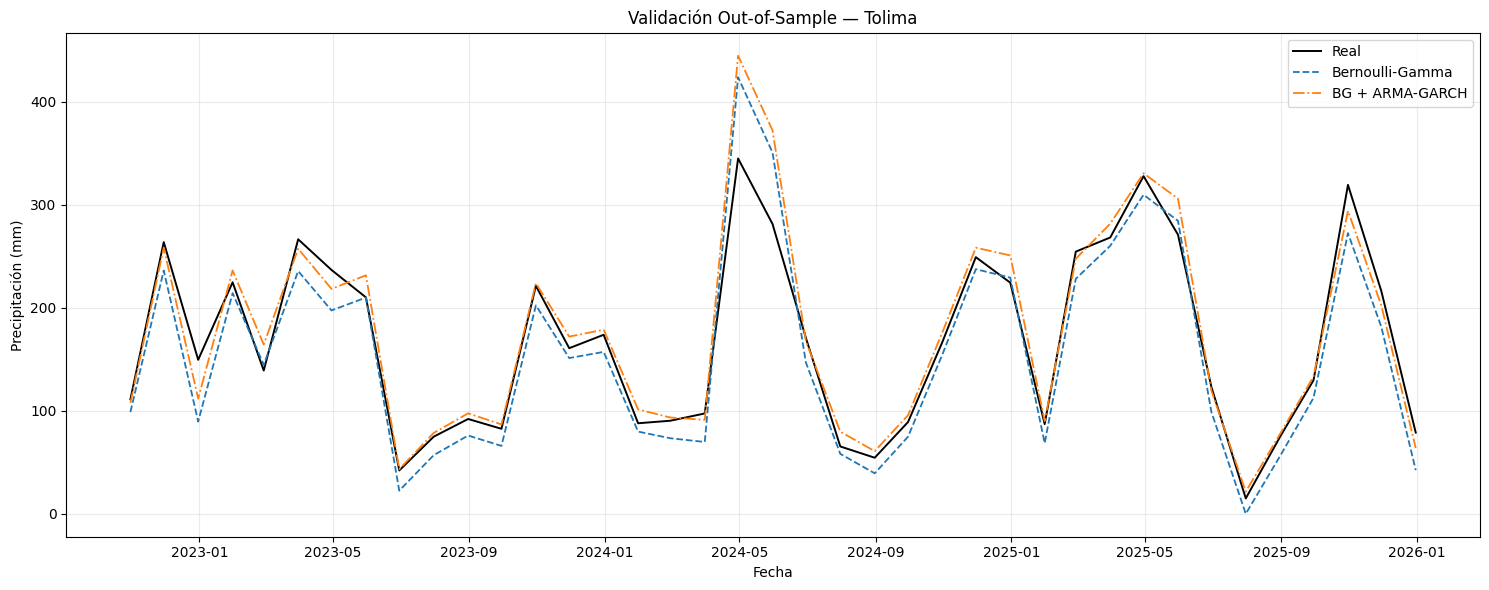

In [4]:
# =============================================================================
# EJECUCIÓN
# =============================================================================

res_casanare = validar_modelos_precipitacion(
    df_Casanare,
    nombre_dpto='Casanare',
    frecuencia='mensual',
    threshold=5
)

res_tolima = validar_modelos_precipitacion(
    df_Tolima,
    nombre_dpto='Tolima',
    frecuencia='mensual',
    threshold=5
)